# WideResNet50 Benchmark

In [1]:
model_name = "WideResNet50"

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def compile_str(mlir):
    return iree.runtime.load_vm_flatbuffer(
        iree.compiler.compile_str(
            mlir, input_type="tosa", target_backends=["llvm-cpu"],
            extra_args=[
                "--iree-llvmcpu-target-cpu-features=host",
                "--iree-stream-partitioning-favor=max-concurrency",
                "--iree-flow-zero-fill-empty-tensors",
                "--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0",
                "--iree-opt-const-eval",
                "--iree-opt-const-expr-hoisting",
                "--iree-opt-numeric-precision-reduction",
                "--iree-opt-strip-assertions"
            ]
        ),
        backend="llvm-cpu"
    )

def compile_file(filename):
    with open(filename) as f:
        return compile_str(f.read())
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Prepare

In [2]:
model = tf.function(tf.saved_model.load("model").signatures["serving_default"])

recompute, storeall = [
    compile_file(x) for x in ["../recompute.mlir", "../storeall.mlir"]
]

2023-07-14 17:56:44.648821: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## Experimental

In [3]:
image = tf.random.normal((1, 3, 224, 224))

with tf.GradientTape(persistent=True) as tape:
    tape.watch(image)
    output = list(model(image).values()).pop()
    
grad = tf.random.normal((1, 1000))

image_np = image.numpy()
grad_np = grad.numpy()

df = pd.DataFrame()

### TensorFlow (Baseline)

In [4]:
baseline_f = timeit("model(image)")
baseline_b = timeit("tape.gradient(output, image, grad)")
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "TensorFlow")])

### Nabla without Optim

In [5]:
f = timeit("recompute.forward(image_np)")
b = timeit("recompute.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla")])

### Nabla with Optim

In [6]:
f = timeit("storeall.forward(image_np)")
b = timeit("storeall.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla Optim")])

## Result

In [7]:
df.to_csv(f"{model_name}-time.csv")
df.style.hide(axis="index")

time,pass,item
91.479863,Forward,TensorFlow
264.028107,Backward,TensorFlow
355.507970,Full,TensorFlow
107.415756,Forward,Nabla
580.497018,Backward,Nabla
687.912774,Full,Nabla
123.427618,Forward,Nabla Optim
412.511514,Backward,Nabla Optim
535.939133,Full,Nabla Optim


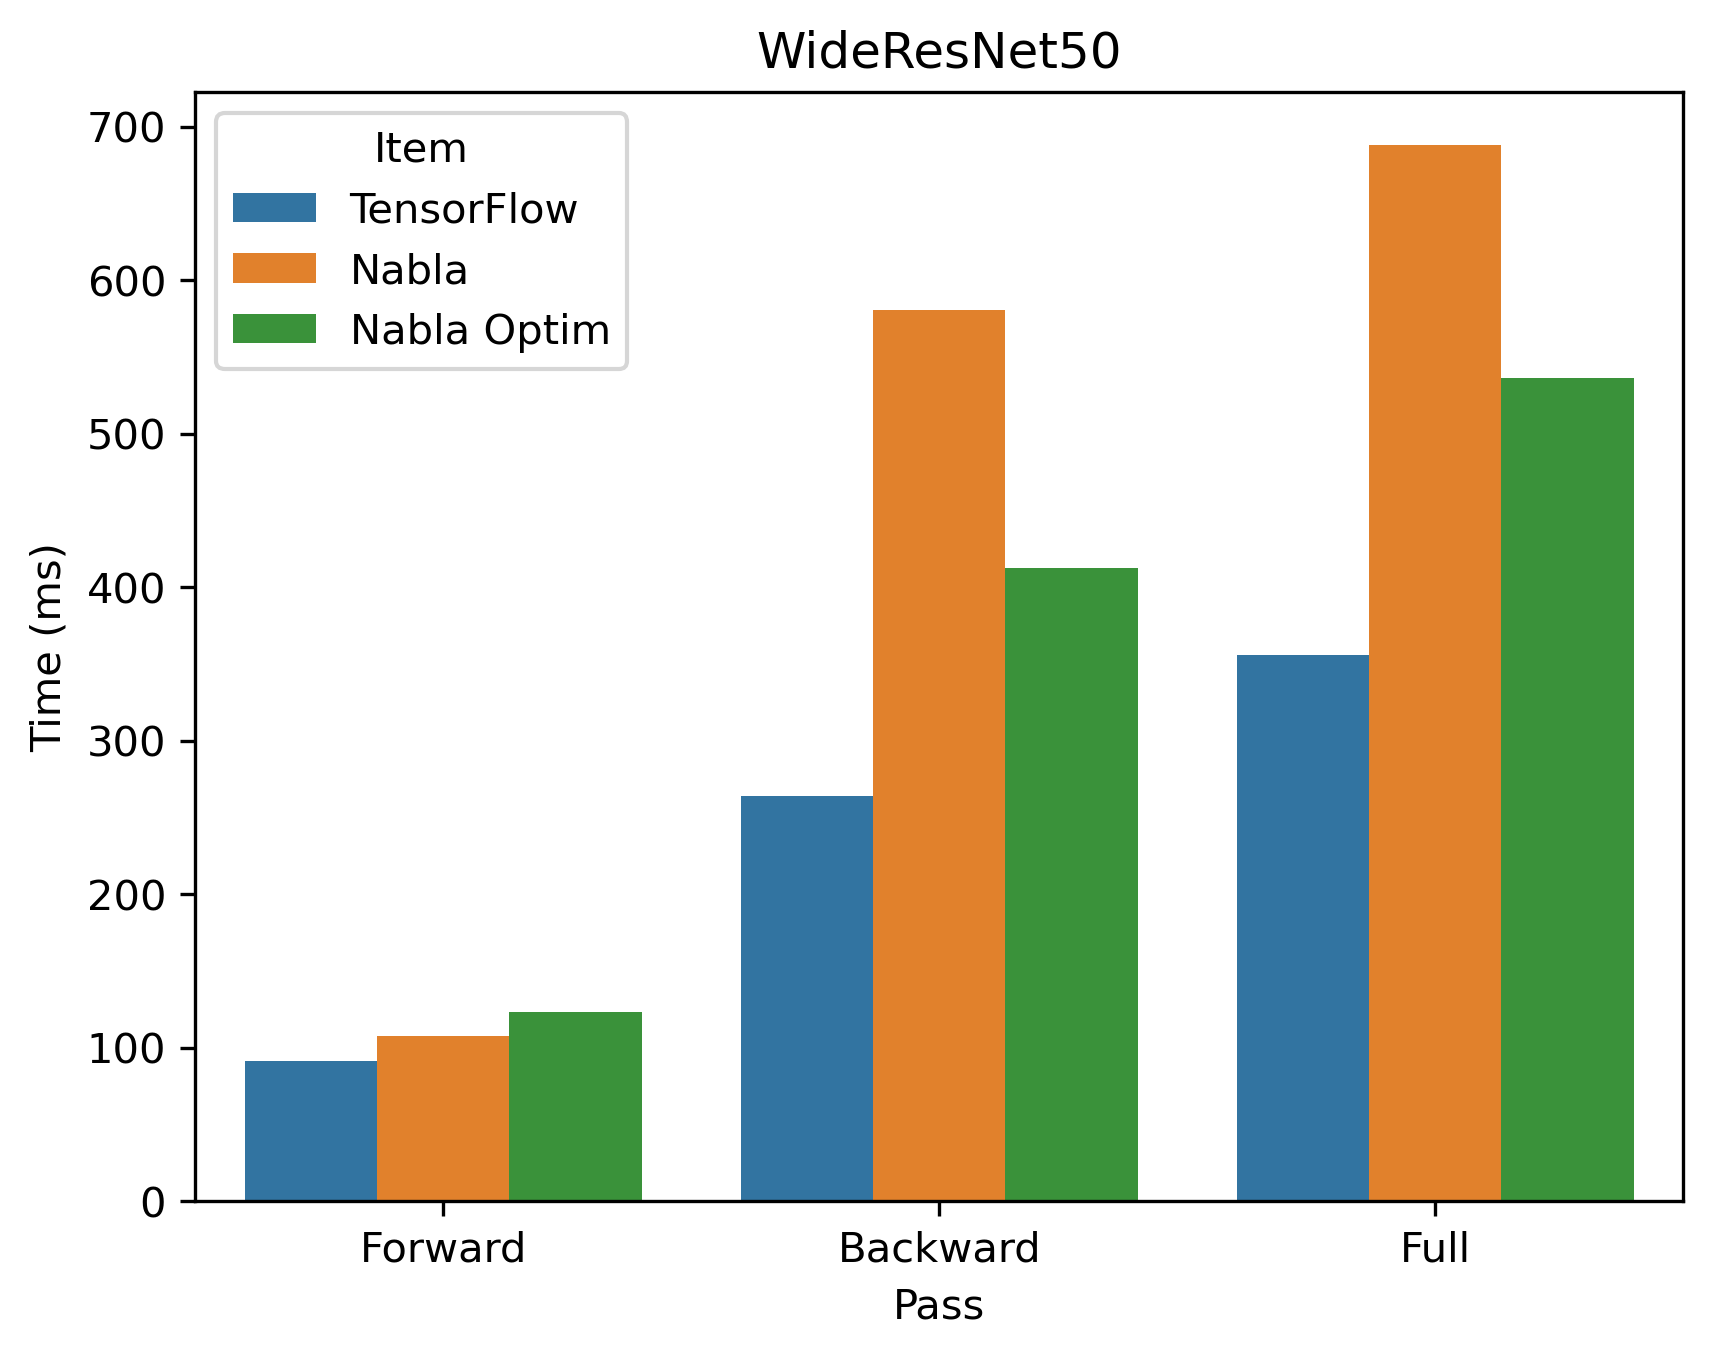

In [8]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [9]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,91.479863,Forward,TensorFlow,1.000000
0,107.415756,Forward,Nabla,0.851643
0,123.427618,Forward,Nabla Optim,0.741162


In [10]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,264.028107,Backward,TensorFlow,1.000000
0,580.497018,Backward,Nabla,0.454831
0,412.511514,Backward,Nabla Optim,0.640050


In [11]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,355.507970,Full,TensorFlow,1.000000
0,687.912774,Full,Nabla,0.516792
0,535.939133,Full,Nabla Optim,0.663336


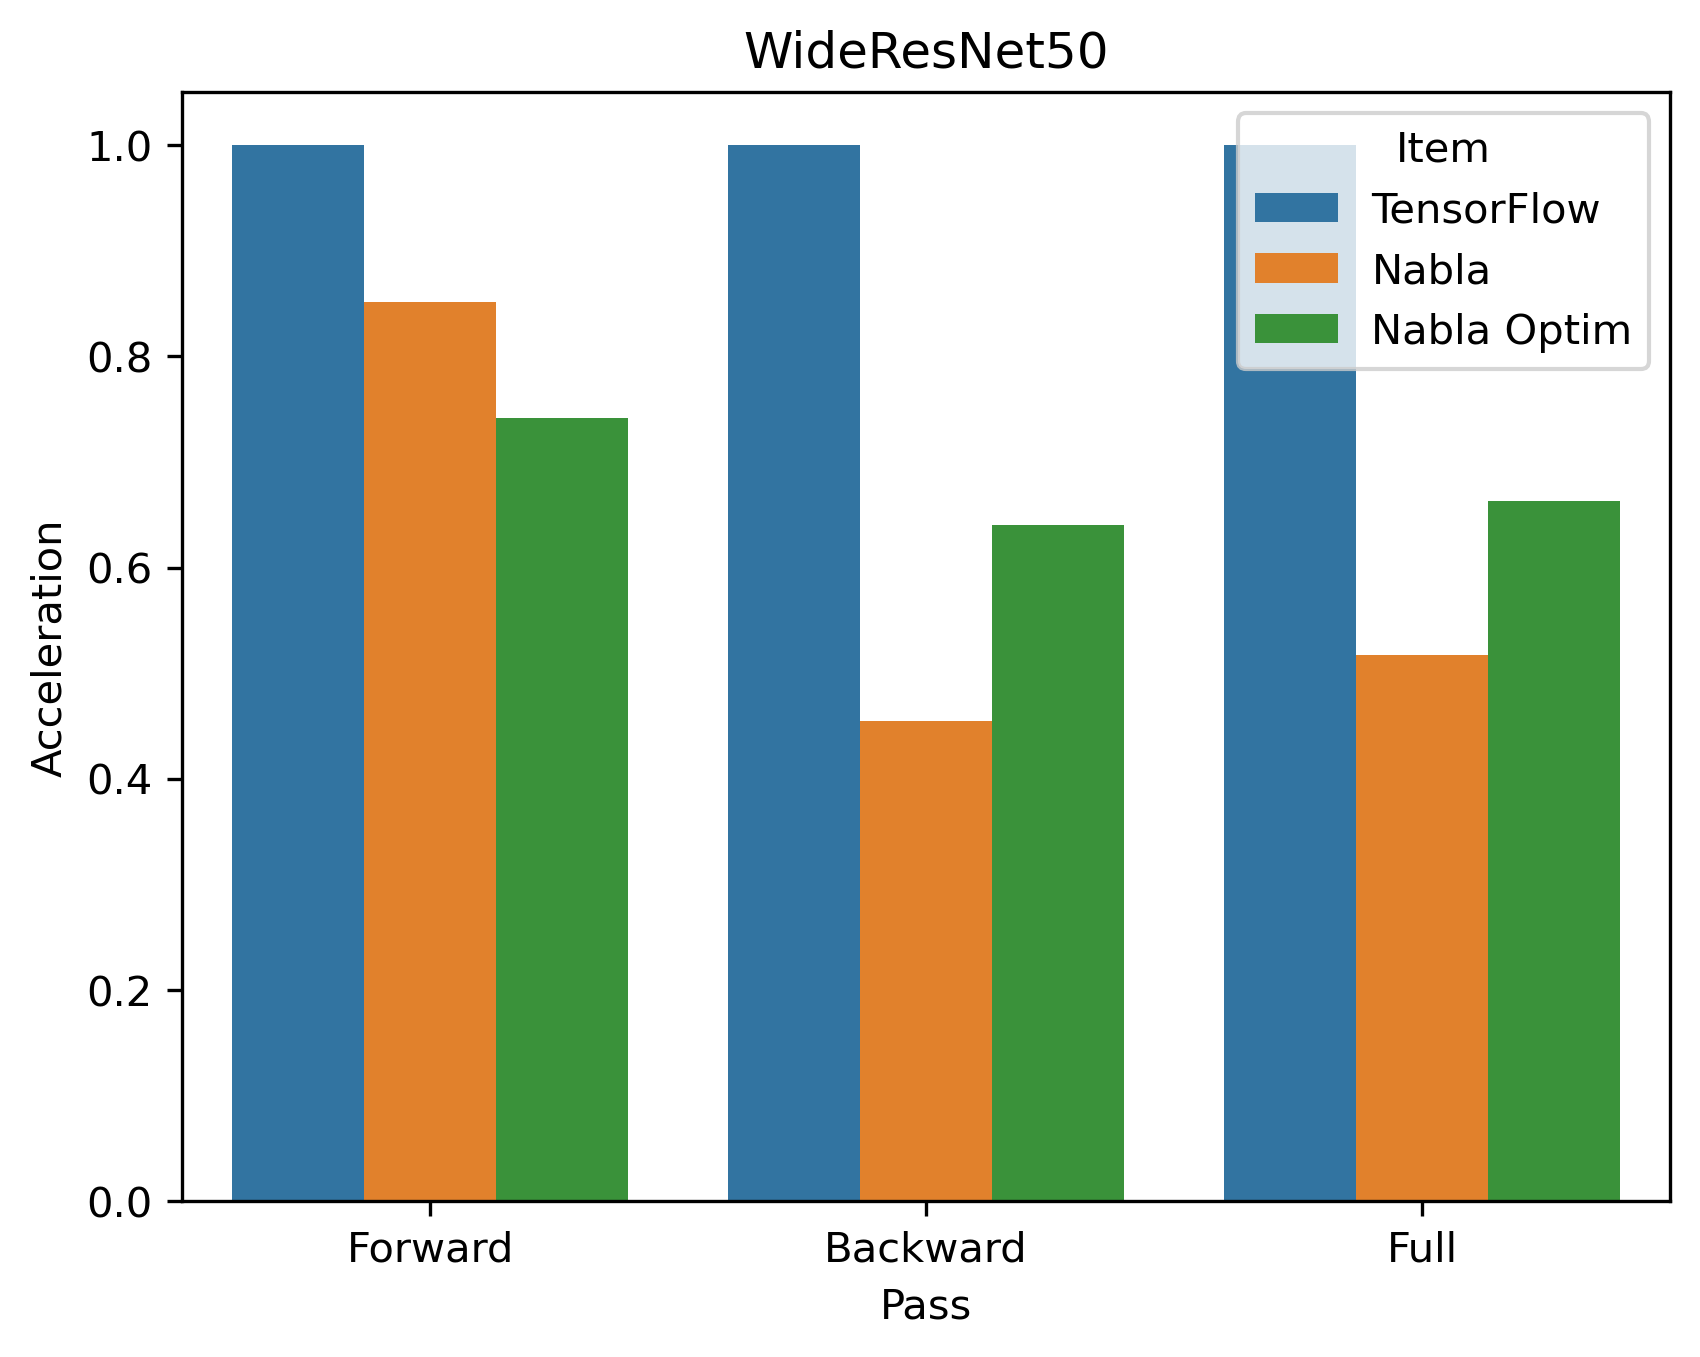

In [12]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}-acceleration.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")